<a href="https://colab.research.google.com/github/prakash323/ACO/blob/main/Differentiated_Thyroid_Cancer_Recurrence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
%matplotlib inline

import matplotlib.pyplot as plt
import missingno as msno
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from scipy import stats
from scipy.stats import norm, skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
import optuna
import xgboost as xgb
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier
import lightgbm as lgbm
from lightgbm import LGBMClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lightgbm import *
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
train = pd.read_csv('/content/Thyroid_Diff.csv')
display(train)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


train


Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

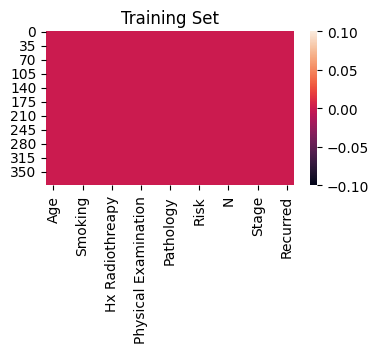

In [ ]:
print('train')
display(train.isnull().sum())

plt.figure(figsize = (4, 2))
plt.title("Training Set")
sns.heatmap(train.isnull())
plt.show()

In [ ]:
print('train')
display(train.info())

train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null

None

In [ ]:


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Gender'] = le.fit_transform(train['Gender'])
train['Smoking'] = le.fit_transform(train['Smoking'])
train['Hx Smoking'] = le.fit_transform(train['Hx Smoking'])
train['Hx Radiothreapy'] = le.fit_transform(train['Hx Radiothreapy'])
train['Thyroid Function'] = le.fit_transform(train['Thyroid Function'])
train['Physical Examination'] = le.fit_transform(train['Physical Examination'])
train['Adenopathy'] = le.fit_transform(train['Adenopathy'])
train['Pathology'] = le.fit_transform(train['Pathology'])
train['Focality'] = le.fit_transform(train['Focality'])
train['Risk'] = le.fit_transform(train['Risk'])
train['T'] = le.fit_transform(train['T'])
train['N'] = le.fit_transform(train['N'])
train['M'] = le.fit_transform(train['M'])
train['Stage'] = le.fit_transform(train['Stage'])
train['Response'] = le.fit_transform(train['Response'])
train['Recurred'] = le.fit_transform(train['Recurred'])
display(train)



,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,1,1,1,1,2,4,5,3,1,0,6,2,1,4,0,1
379,81,1,1,0,1,2,1,1,3,0,0,6,2,1,4,3,1
380,72,1,1,1,0,2,1,0,3,0,0,6,2,1,4,3,1
381,61,1,1,1,1,0,1,1,1,0,0,6,2,0,3,3,1


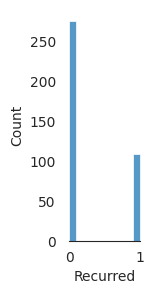

Skewness: 0.972847
Kurtosis: -1.059128


In [ ]:


sns.set_style("white")
sns.set_color_codes(palette='deep')
f, ax = plt.subplots(figsize=(1, 3))
sns.histplot(train['Recurred'])
ax.xaxis.grid(False)

sns.despine(trim=True, left=True)
plt.show()

print("Skewness: %f" % train['Recurred'].skew())
print("Kurtosis: %f" % train['Recurred'].kurt())



<catboost.co: 
 [7.78519668e+00 1.65905550e+00 3.44302583e-01 8.91437737e-02
 3.58860092e-02 2.17351459e+00 8.54749213e+00 2.34178274e+00
 2.83613834e+00 1.91676593e+00 8.61745172e+00 3.83512373e+00
 5.23752956e+00 3.33700013e-02 1.69388725e+00 5.28533595e+01]


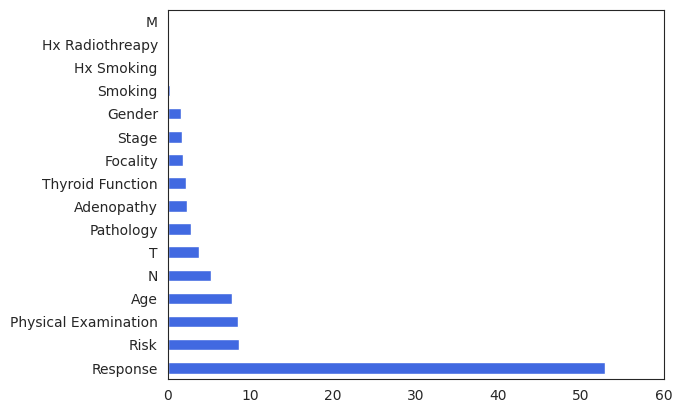

In [ ]:
X_data_feature= train.drop(columns=['Recurred'],axis=1)
y_data_feature= train['Recurred']

model = [CatBoostClassifier(logging_level='Silent')]

model = [model[i].fit(X_data_feature,y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ': \n',
          model[i].feature_importances_)
    feat_importances = pd.Series(model[i].feature_importances_,
                                 index=X_data_feature.columns)
    feat_importances.nlargest(16).plot(kind='barh', color='royalblue')
    plt.xlim(0, 60)
    plt.show()

XGBClassifie: 
 [0.02926455 0.03294632 0.         0.         0.         0.
 0.01881094 0.04260206 0.02147898 0.00615993 0.21278603 0.01971849
 0.02218023 0.         0.06906602 0.5249864 ]


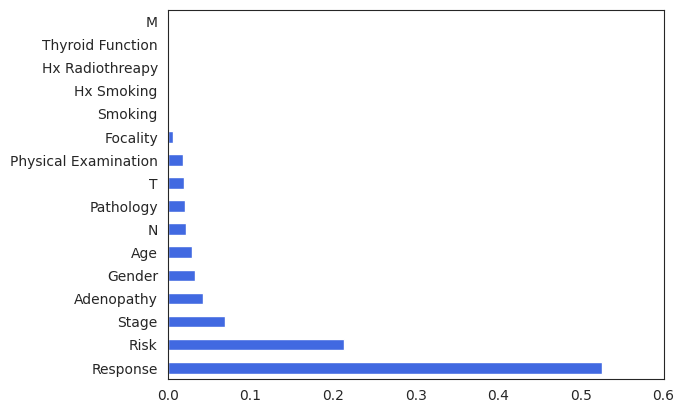

In [ ]:
model = [XGBClassifier()]

model = [model[i].fit(X_data_feature,y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ': \n',
          model[i].feature_importances_)
    feat_importances = pd.Series(model[i].feature_importances_,
                                 index=X_data_feature.columns)
    feat_importances.nlargest(16).plot(kind='barh', color='royalblue')
    plt.xlim(0, 0.6)
    plt.show()

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 108, number of negative: 275
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 102
[LightGBM] [Info] Number of data points in the train set: 383, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.281984 -> initscore=-0.934640
[LightGBM] [Info] Start training from score -0.934640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

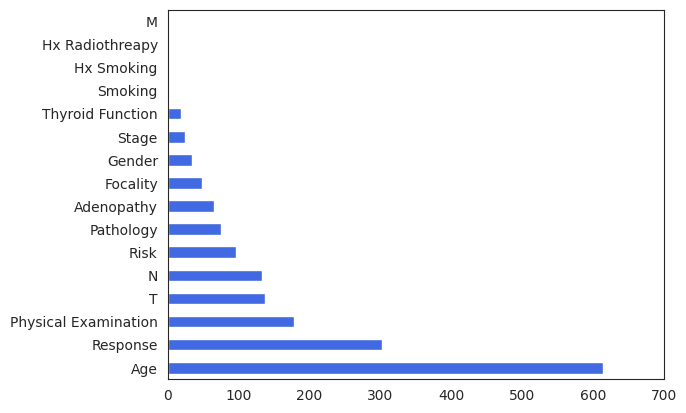

In [ ]:


model = [LGBMClassifier()]

model = [model[i].fit(X_data_feature,y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ': \n',
          model[i].feature_importances_)
    feat_importances = pd.Series(model[i].feature_importances_,
                                 index=X_data_feature.columns)
    feat_importances.nlargest(16).plot(kind='barh', color='royalblue')
    plt.xlim(0, 700)
    plt.show()



In [ ]:


train=train.drop(columns=['M', 'Hx Radiothreapy', 'Hx Smoking', 'Smoking'],axis=1)



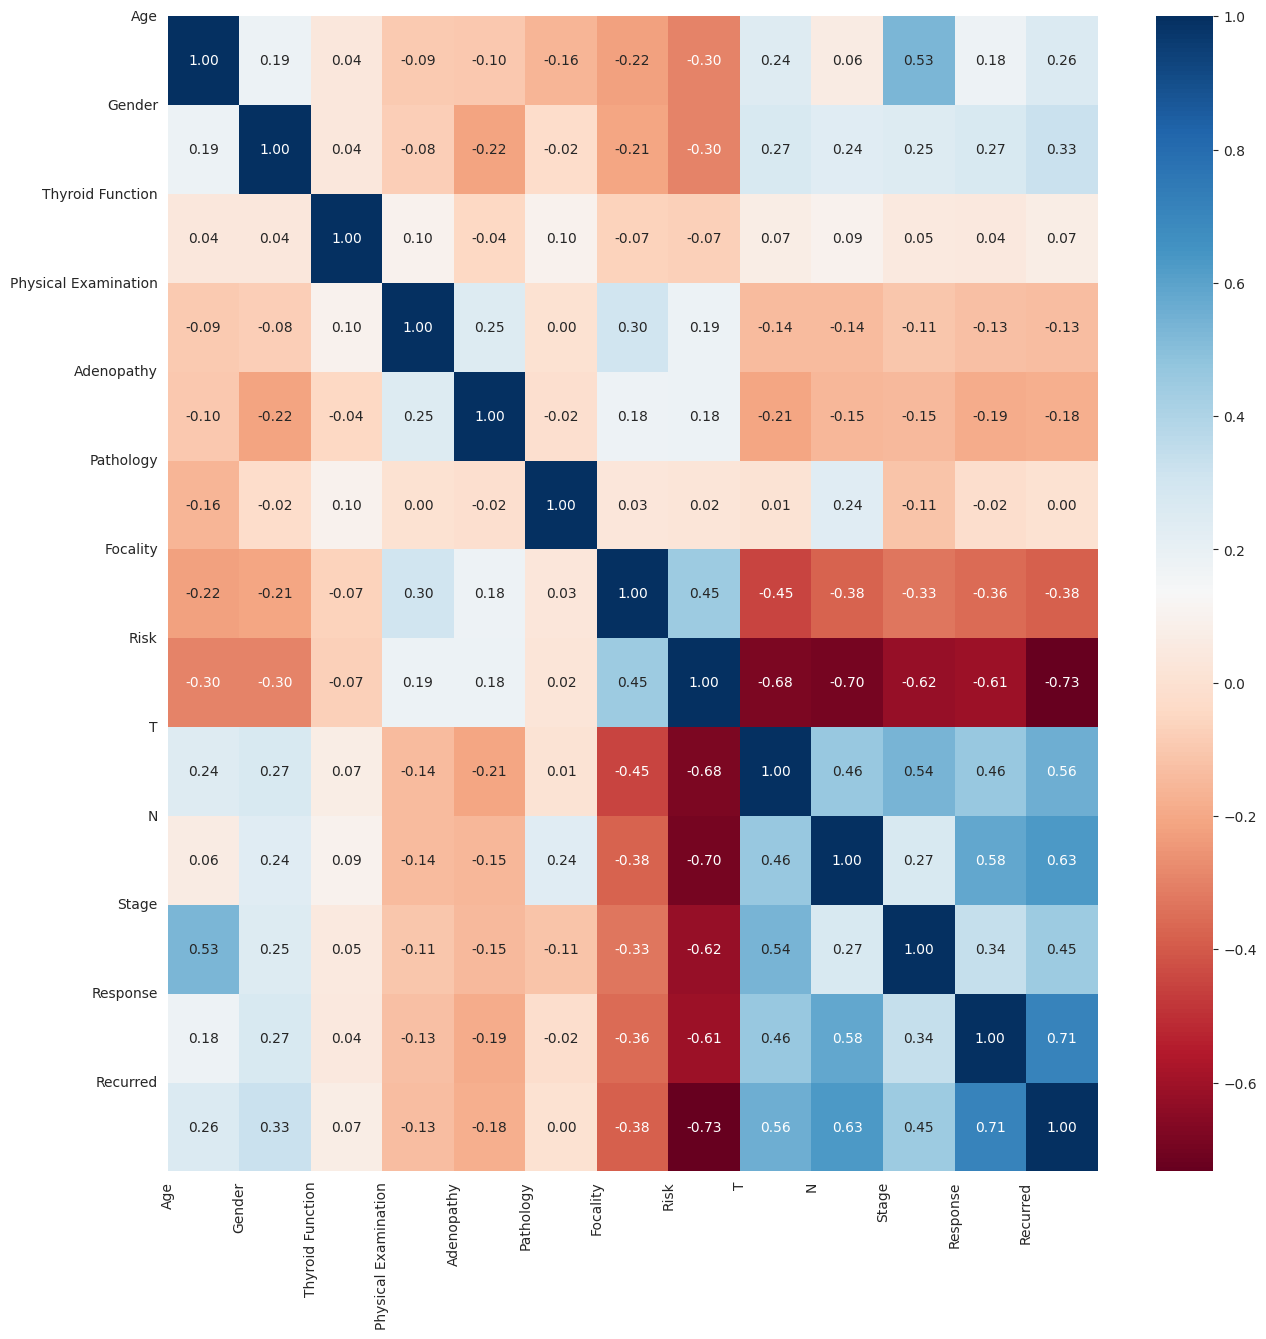

In [ ]:
corr = train.corr(method='pearson')
fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(corr, cmap='RdBu', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns);
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [ ]:
X= train.drop(columns=['Recurred'],axis=1)
y= train['Recurred']

In [ ]:


from sklearn.preprocessing import MinMaxScaler

X_train=X
y_train=y

MinMaxScaler = MinMaxScaler()
X_train = MinMaxScaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train)
X_train



,0,1,2,3,4,5,6,7,8,9,10,11
0,0.179104,0.0,0.5,0.75,0.6,0.666667,1.0,1.0,0.0,0.0,0.00,0.666667
1,0.283582,0.0,0.5,0.25,0.6,0.666667,1.0,1.0,0.0,0.0,0.00,0.333333
2,0.223881,0.0,0.5,1.00,0.6,0.666667,1.0,1.0,0.0,0.0,0.00,0.333333
3,0.701493,0.0,0.5,1.00,0.6,0.666667,1.0,1.0,0.0,0.0,0.00,0.333333
4,0.701493,0.0,0.5,0.25,0.6,0.666667,0.0,1.0,0.0,0.0,0.00,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
378,0.850746,1.0,0.5,1.00,1.0,1.000000,1.0,0.0,1.0,1.0,1.00,0.000000
379,0.985075,1.0,0.5,0.25,0.2,1.000000,0.0,0.0,1.0,1.0,1.00,1.000000
380,0.850746,1.0,0.5,0.25,0.0,1.000000,0.0,0.0,1.0,1.0,1.00,1.000000
381,0.686567,1.0,0.0,0.25,0.2,0.333333,0.0,0.0,1.0,1.0,0.75,1.000000


In [ ]:
X_train, X_eval, y_train, y_eval = train_test_split(X_train, y_train,test_size=0.2,random_state=2019)
print("Shape of X_train: ",X_train.shape)
print("Shape of X_eval: ", X_eval.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_eval",y_eval.shape)

Shape of X_train:  (306, 12)
Shape of X_eval:  (77, 12)
Shape of y_train:  (306,)
Shape of y_eval (77,)


In [ ]:
!pip install lazypredict
from lazypredict.Supervised import LazyClassifier

In [ ]:


clf = LazyClassifier()
models, predictions = clf.fit(X_train, X_eval, y_train, y_eval)



100%|██████████| 29/29 [00:02<00:00, 11.83it/s]

[LightGBM] [Info] Number of positive: 86, number of negative: 220
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 102
[LightGBM] [Info] Number of data points in the train set: 306, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.281046 -> initscore=-0.939280
[LightGBM] [Info] Start training from score -0.939280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
print(models)

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
BaggingClassifier                  0.97               0.97     0.97      0.97   
DecisionTreeClassifier             0.96               0.96     0.96      0.96   
LGBMClassifier                     0.96               0.95     0.95      0.96   
XGBClassifier                      0.96               0.95     0.95      0.96   
RandomForestClassifier             0.96               0.95     0.95      0.96   
ExtraTreesClassifier               0.95               0.94     0.94      0.95   
AdaBoostClassifier                 0.95               0.94     0.94      0.95   
ExtraTreeClassifier                0.90               0.89     0.89      0.90   
QuadraticDiscriminantAnalysis      0.88               0.88     0.88      0.89   
GaussianNB                         0.88               0.88     0.88      0.89   
NearestCentroid             

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier
from sklearn.ensemble import  AdaBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier

clf1 = BaggingClassifier()
clf2 = DecisionTreeClassifier()
clf3 = ExtraTreesClassifier()
clf4 = RandomForestClassifier()
clf5 = LGBMClassifier()
clf6 = XGBClassifier()
clf7 = AdaBoostClassifier()

In [ ]:
clf1 = clf1.fit(X_train, y_train)
clf2 = clf2.fit(X_train, y_train)
clf3 = clf3.fit(X_train, y_train)
clf4 = clf4.fit(X_train, y_train)
clf5 = clf5.fit(X_train, y_train)
clf6 = clf6.fit(X_train, y_train)
clf7 = clf7.fit(X_train, y_train)

eclf = VotingClassifier(estimators=[('BC', clf1), ('DT', clf2), ('ETSC', clf3), ('RTC', clf4), ('LGBM', clf5),
                                    ('XGB', clf6), ('ABC', clf7)],voting='hard')
Voting_model = eclf.fit(X_train, y_train)

y_pred_Voting = Voting_model.predict(X_eval)

[LightGBM] [Info] Number of positive: 86, number of negative: 220
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 306, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.281046 -> initscore=-0.939280
[LightGBM] [Info] Start training from score -0.939280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

Voting accuracy is: 96.104%


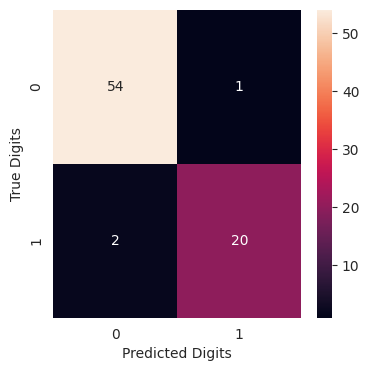

In [ ]:
Voting_acc = accuracy_score(y_eval, y_pred_Voting)
print("Voting accuracy is: {0:.3f}%".format(Voting_acc * 100))
cm = confusion_matrix(y_eval, y_pred_Voting)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='.0f')
plt.xlabel("Predicted Digits")
plt.ylabel("True Digits")
plt.show()